# 3. Model Evaluation

Este notebook conecta los motores modulares de `src/` con una capa narrativa orientada a evaluación comparativa. Se priorizan **Recall** y **F1-Score** por el desbalance del 4.9% en la clase positiva de ACV.

In [5]:
from pathlib import Path
import sys
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_preprocessing import build_feature_preprocessor, load_raw_dataset, split_features_target
from src.model_evaluation import (
    build_stratified_kfold,
    confusion_matrix_report,
    print_model_comparison_report,
    roc_curve_points,
)
from src.model_training import build_model_pipelines

results_metrics_dir = PROJECT_ROOT / 'results' / 'metrics'
results_plots_dir = PROJECT_ROOT / 'results' / 'plots'
results_metrics_dir.mkdir(parents=True, exist_ok=True)
results_plots_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')


In [6]:
data_path = PROJECT_ROOT / 'data' / 'raw' / 'healthcare-dataset-stroke-data.csv'
df_raw = load_raw_dataset(data_path)

X_raw, y_raw = split_features_target(df_raw, target='stroke', drop_columns=('id',))
feature_preprocessor = build_feature_preprocessor(X_raw)
model_pipelines = build_model_pipelines(feature_preprocessor=feature_preprocessor, random_state=42)
cv = build_stratified_kfold(n_splits=5, random_state=42)

print(f'Dataset cargado desde: {data_path}')
print(f'Observaciones: {len(df_raw)}')
print(f'Variables predictoras: {X_raw.shape[1]}')
print('Modelos evaluados:', ', '.join(model_pipelines.keys()))


Dataset cargado desde: /home/tomy/Downloads/cdd_ev2/mi_proyecto/data/raw/healthcare-dataset-stroke-data.csv
Observaciones: 5110
Variables predictoras: 10
Modelos evaluados: logistic_regression, random_forest, svc


In [7]:
baseline_summary = print_model_comparison_report(
    models=model_pipelines,
    X=X_raw,
    y=y_raw,
    cv=cv,
    random_state=42,
)

baseline_summary = baseline_summary.sort_values(
    by=['recall_mean', 'f1_mean', 'roc_auc_mean', 'precision_mean'],
    ascending=[False, False, False, False],
).reset_index(drop=True)

baseline_summary.to_csv(results_metrics_dir / 'baseline_model_comparison.csv', index=False)
baseline_summary



=== Comparacion de modelos ===
              model  precision_mean  precision_std  recall_mean  recall_std  f1_mean   f1_std  roc_auc_mean  roc_auc_std
logistic_regression        0.130771       0.009227     0.802939    0.060460 0.224889 0.015831      0.834207     0.024556
                svc        0.121665       0.015607     0.702367    0.075616 0.207377 0.025883      0.798383     0.025469
      random_forest        0.198333       0.142449     0.020082    0.014143 0.036137 0.025286      0.771874     0.034032


,model,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,logistic_regression,0.130771,0.009227,0.802939,0.060460,0.224889,0.015831,0.834207,0.024556
1,svc,0.121665,0.015607,0.702367,0.075616,0.207377,0.025883,0.798383,0.025469
2,random_forest,0.198333,0.142449,0.020082,0.014143,0.036137,0.025286,0.771874,0.034032


In [8]:
baseline_summary = print_model_comparison_report(
    models=model_pipelines,
    X=X_raw,
    y=y_raw,
    cv=cv,
    random_state=42,
)

baseline_summary = baseline_summary.sort_values(
    by=['recall_mean', 'f1_mean', 'roc_auc_mean', 'precision_mean'],
    ascending=[False, False, False, False],
).reset_index(drop=True)

baseline_summary.to_csv(metrics_dir / 'baseline_model_comparison.csv', index=False)
baseline_summary.to_json(metrics_dir / 'baseline_model_comparison.json', orient='records', indent=2)
baseline_summary


=== Comparacion de modelos ===
              model  precision_mean  precision_std  recall_mean  recall_std  f1_mean   f1_std  roc_auc_mean  roc_auc_std
logistic_regression        0.130771       0.009227     0.802939    0.060460 0.224889 0.015831      0.834207     0.024556
                svc        0.121665       0.015607     0.702367    0.075616 0.207377 0.025883      0.798383     0.025469
      random_forest        0.198333       0.142449     0.020082    0.014143 0.036137 0.025286      0.771874     0.034032


NameError: name 'metrics_dir' is not defined

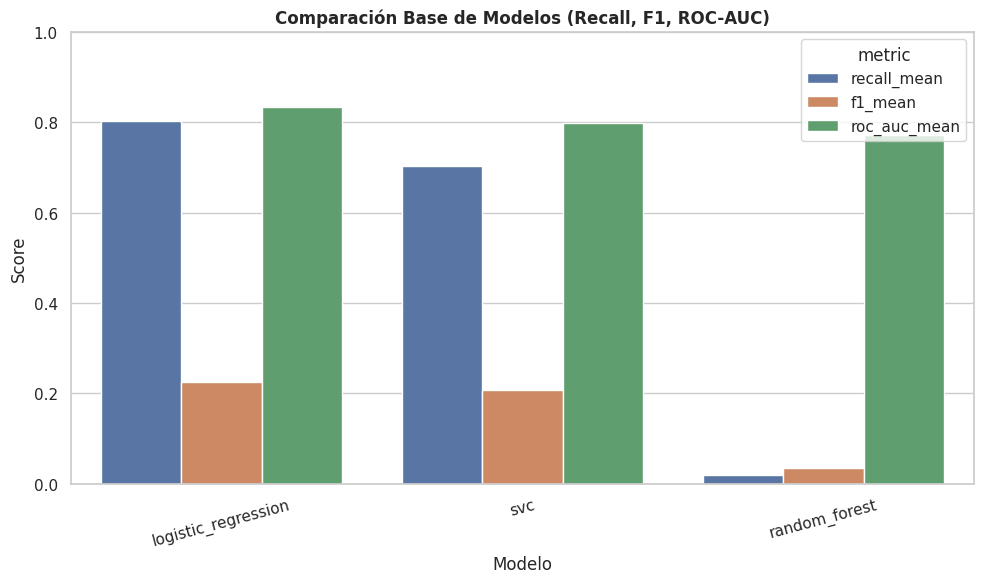

In [ ]:
plt.figure(figsize=(10, 6))
plot_df = baseline_summary.melt(
    id_vars='model',
    value_vars=['recall_mean', 'f1_mean', 'roc_auc_mean'],
    var_name='metric',
    value_name='score',
)
sns.barplot(data=plot_df, x='model', y='score', hue='metric')
plt.title('Comparación Base de Modelos (Recall, F1, ROC-AUC)', fontweight='bold')
plt.xlabel('Modelo')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(plots_dir / 'baseline_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    stratify=y_raw,
    random_state=42,
)

holdout_rows = []
roc_frames = []
fitted_models = {}

for model_name, pipeline in model_pipelines.items():
    pipeline.fit(X_train, y_train)
    fitted_models[model_name] = pipeline
    y_pred = pipeline.predict(X_test)
    y_score = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline, 'predict_proba') else pipeline.decision_function(X_test)

    holdout_rows.append({
        'model': model_name,
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_score),
    })

    roc_df = roc_curve_points(y_test, y_score)
    roc_df['model'] = model_name
    roc_frames.append(roc_df)

holdout_metrics = pd.DataFrame(holdout_rows).sort_values(
    by=['recall', 'f1', 'roc_auc', 'precision'],
    ascending=[False, False, False, False],
).reset_index(drop=True)
holdout_metrics.to_csv(metrics_dir / 'baseline_holdout_metrics.csv', index=False)
holdout_metrics.to_json(metrics_dir / 'baseline_holdout_metrics.json', orient='records', indent=2)
holdout_metrics

,model,precision,recall,f1,roc_auc
0,logistic_regression,0.137457,0.80,0.234604,0.843210
1,svc,0.130137,0.76,0.222222,0.799835
2,random_forest,0.090909,0.02,0.032787,0.746204


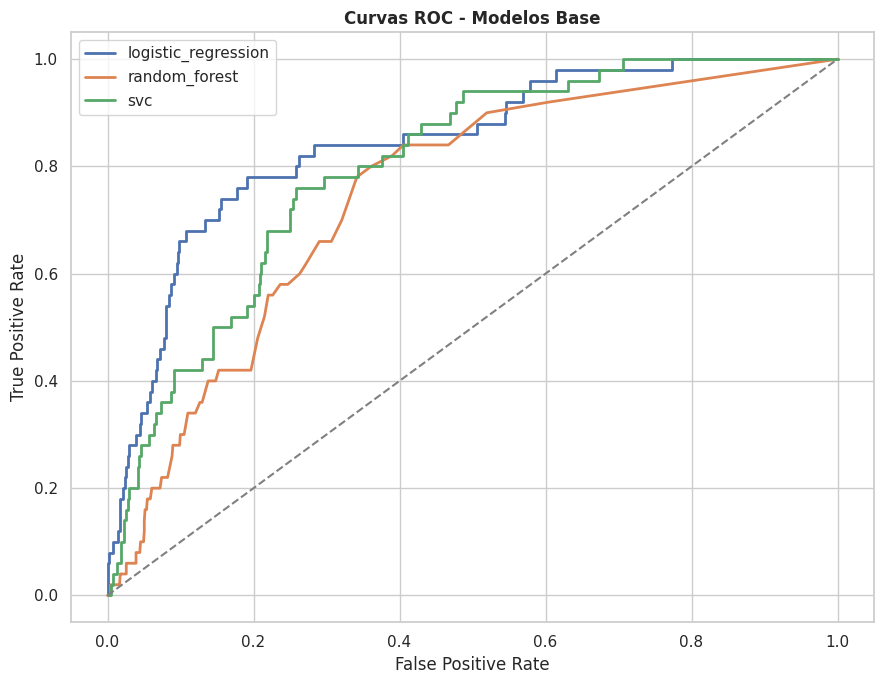

In [ ]:
roc_plot_df = pd.concat(roc_frames, ignore_index=True)

plt.figure(figsize=(9, 7))
for model_name in roc_plot_df['model'].unique():
    subset = roc_plot_df[roc_plot_df['model'] == model_name]
    plt.plot(subset['fpr'], subset['tpr'], linewidth=2, label=model_name)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Curvas ROC - Modelos Base', fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig(plots_dir / 'baseline_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

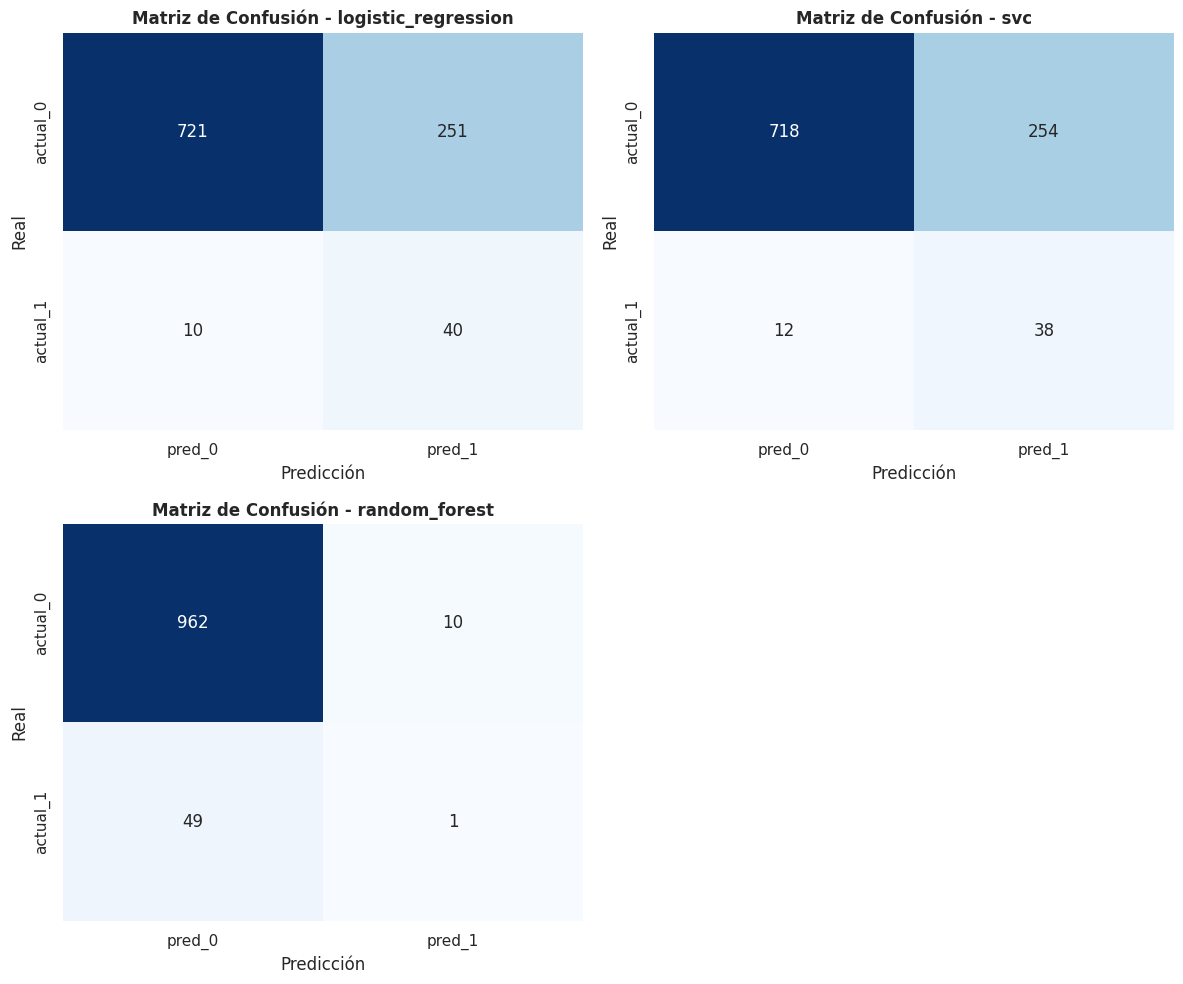

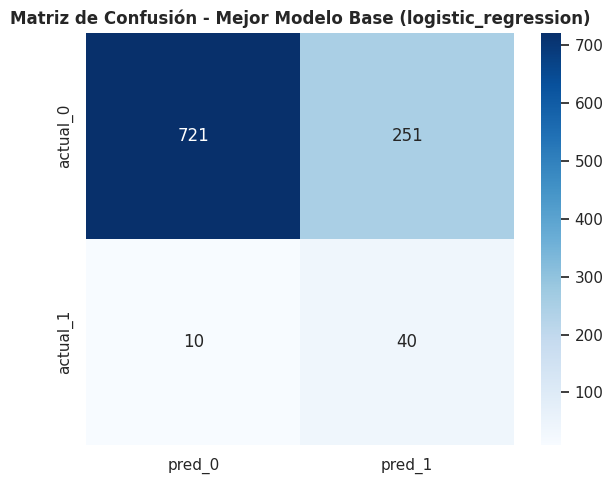

Mejor modelo base por holdout: logistic_regression


,model,precision,recall,f1,roc_auc
0,logistic_regression,0.137457,0.80,0.234604,0.843210
1,svc,0.130137,0.76,0.222222,0.799835
2,random_forest,0.090909,0.02,0.032787,0.746204


In [ ]:
best_model_name = holdout_metrics.iloc[0]['model']

confusion_rows = []
ordered_models = holdout_metrics['model'].tolist()
n_models = len(ordered_models)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, model_name in zip(axes, ordered_models):
    model = fitted_models[model_name]
    y_pred = model.predict(X_test)
    cm_df = confusion_matrix_report(y_test, y_pred)

    for actual_label, row in cm_df.iterrows():
        for predicted_label, value in row.items():
            confusion_rows.append({
                'model': model_name,
                'actual': actual_label,
                'predicted': predicted_label,
                'count': int(value),
            })

    sns.heatmap(cm_df, annot=True, fmt='g', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'Matriz de Confusión - {model_name}', fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

for ax in axes[n_models:]:
    ax.axis('off')

confusion_long_df = pd.DataFrame(confusion_rows)
confusion_long_df.to_csv(metrics_dir / 'baseline_confusion_matrices.csv', index=False)

plt.tight_layout()
plt.savefig(plots_dir / 'baseline_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

best_model = fitted_models[best_model_name]
y_best_pred = best_model.predict(X_test)
best_cm_df = confusion_matrix_report(y_test, y_best_pred)
best_cm_df.to_csv(metrics_dir / 'baseline_best_confusion_matrix.csv')

plt.figure(figsize=(6, 5))
sns.heatmap(best_cm_df, annot=True, fmt='g', cmap='Blues')
plt.title(f'Matriz de Confusión - Mejor Modelo Base ({best_model_name})', fontweight='bold')
plt.tight_layout()
plt.savefig(plots_dir / 'baseline_best_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mejor modelo base por holdout: {best_model_name}')
holdout_metrics.head(3)
